# HW1 - Fraudulent Transaction Detection

In [2]:
# Librairies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2


In [3]:
# Load up the data
data=pd.read_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW1/fraud_homework_features.csv')
print(data.head())

   Transaction_Amount  Items_in_Cart  IP_Reputation_Score  Transaction_vs_Avg
0           25.353281      33.498422            84.242491          -64.575520
1           11.907446      14.056594            89.950839          108.109227
2           80.653014      81.714082            69.661417         -130.487596
3           39.446720      43.868760            73.230538          -14.848716
4           14.642711      16.271444            61.392552          207.687191


## Data preprocessing

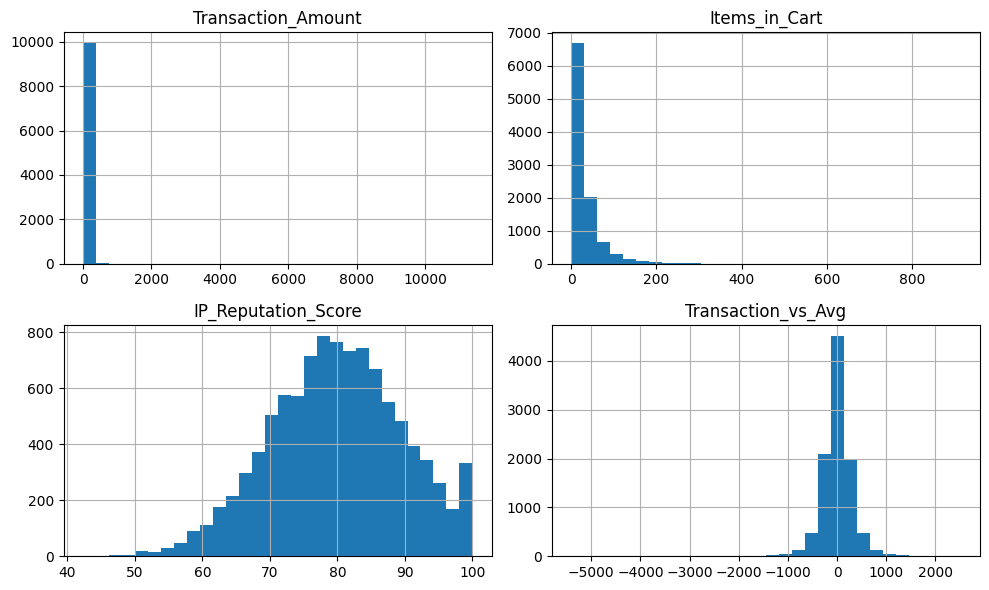

Skewness by variable:
Transaction_Amount     43.249077
Items_in_Cart           4.943540
IP_Reputation_Score    -0.129638
Transaction_vs_Avg     -1.263463
dtype: float64


In [4]:
# Data shape

# Histograms (one per variable)
data.hist(bins=30, figsize=(10,6))
plt.tight_layout()
plt.show()

# Skewness values (rule of thumb: |skew| > 1 → skewed)
print("Skewness by variable:")
print(data.skew())


p24: Our outlier detection methods use a symmetric interval, so the data should not be highly skewed. if it is, 
Applies log() to the transaction amount and number of items because real financial data is usually asymmetric (long right tail).

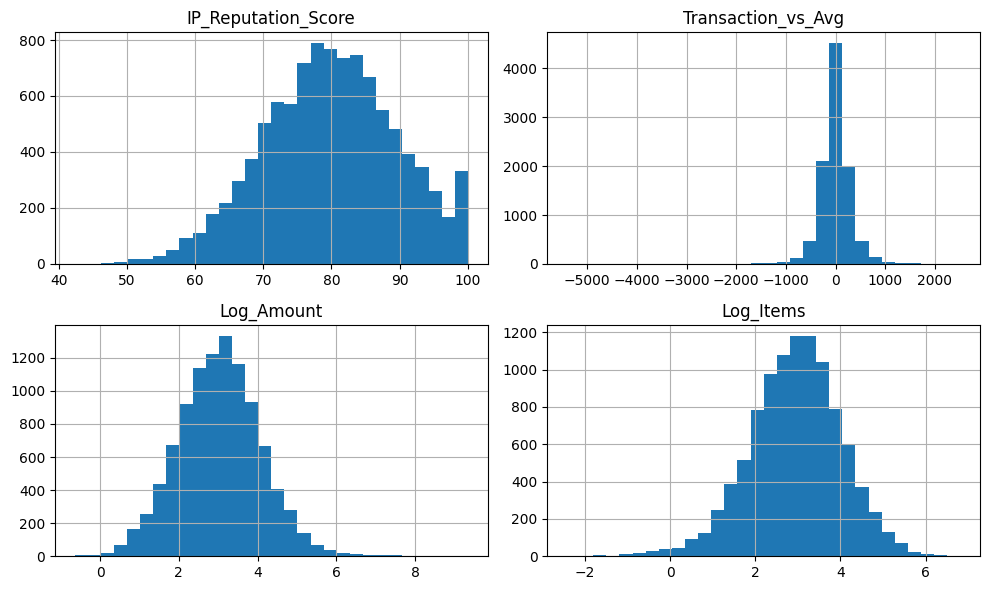

Skewness by variable:
IP_Reputation_Score   -0.129638
Transaction_vs_Avg    -1.263463
Log_Amount             0.255096
Log_Items             -0.390620
dtype: float64


In [5]:
# Applying log to the 2 highly skewed dimensions
data["Log_Amount"] = np.log(data["Transaction_Amount"])
data["Log_Items"] = np.log(data["Items_in_Cart"])
                           
# New histograms
data.iloc[:, -4:].hist(bins=30, figsize=(10,6))
plt.tight_layout()
plt.show()

# New skewness values (rule of thumb: |skew| > 1 → skewed)
print("Skewness by variable:")
print(data.iloc[:, -4:].skew())

better !

## Data analysis

Because we have 4D-data, we are going to use a multivariate outlier detection method.  
We choose the Mahalanobis distance.  

To detect anomalies, we first need to understand what “normal” data looks like.  
We first compute the mean vector, composed of each variable's mean over all transactions.

In [6]:
# Means
X = data.iloc[:, -4:].copy()
mu_X = X.mean().to_frame(name="mean")

print(X.describe())
print(mu_X)

       IP_Reputation_Score  Transaction_vs_Avg    Log_Amount     Log_Items
count         10000.000000        10000.000000  10000.000000  10000.000000
mean             79.906459            0.529391      3.037106      2.932998
std               9.773121          327.071880      1.057202      1.087408
min              42.321547        -5407.608043     -0.651122     -2.424615
25%              73.171734         -148.790082      2.331291      2.257956
50%              80.060172           -1.907666      3.032284      2.974129
75%              86.681326          152.639277      3.711155      3.649713
max             100.000000         2512.332189      9.340484      6.816519
                          mean
IP_Reputation_Score  79.906459
Transaction_vs_Avg    0.529391
Log_Amount            3.037106
Log_Items             2.932998


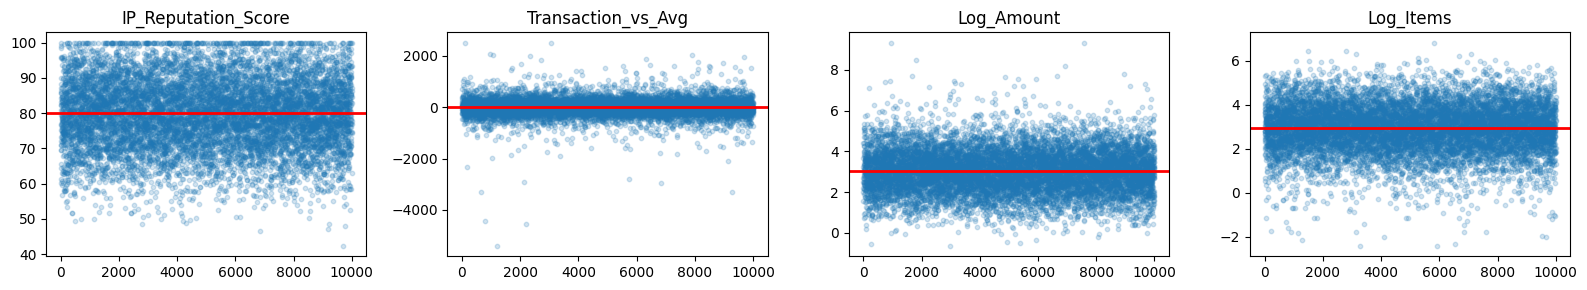

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=False)       # to have side-by-side plot, with different y scales

for i, col in enumerate(X.columns):
    axes[i].scatter(range(len(X)), X[col], s=10, alpha=0.2)         # with transparency
    axes[i].axhline(y=X[col].mean(), color="red", linewidth=2)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


The next step is to calculate the covariance matrix and its inverse.

                     IP_Reputation_Score  Transaction_vs_Avg  Log_Amount  \
IP_Reputation_Score            95.513898           21.452950    0.074264   
Transaction_vs_Avg             21.452950       106976.014757   -1.893130   
Log_Amount                      0.074264           -1.893130    1.117677   
Log_Items                       0.058955           -2.672739    0.822703   

                     Log_Items  
IP_Reputation_Score   0.058955  
Transaction_vs_Avg   -2.672739  
Log_Amount            0.822703  
Log_Items             1.182457  


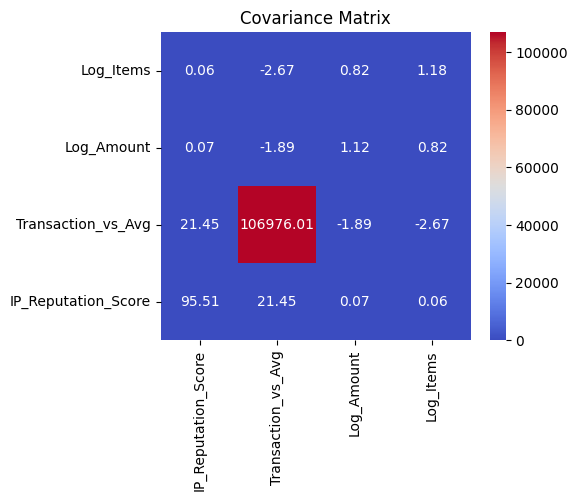

In [8]:
# Covariance matrix
sigma = X.cov()
print(sigma)

# Plotted as heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
sns.heatmap(
    sigma.iloc[::-1],     # reverses the row order so that the cov(X,X)=V(X) are on the diagonal) 
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Covariance Matrix")
plt.show()


In [9]:
# Inverse of covariance matrix
sigma_inv = np.linalg.inv(sigma.values)           # si ça marche c'est qu'elle est inversible dc pas bs de verif

In [10]:
# Mahanalobis distance -- using prof all-in-one function "Mahanalobis_dist"

def mahanalobis_1(data,mu=None,cov=None):
    if(hasattr(data, 'to_numpy')): ## Checking if the input is Numpy type or DataFrame type 
        y = np.array(data.to_numpy(),ndmin=2) ## If not Numpy type: we assume this is a dataframe.
    else:
        y = data
        
    if(np.ndim(y)==1):
        if cov is None:sys.exit('Covariance should be provided')
        
        if mu is None:sys.exit('mu should be provided')
        
        if(np.size(y)==1):
            mana = (y-mu)**2/cov ## Univariate
        else:
            inv_covmat = np.linalg.inv(cov)
            y_mu = np.array(y - mu,ndmin=2) ## array 1xK
            mana = np.matmul(y_mu,np.matmul(inv_covmat,y_mu.transpose()))
    else:
        if(np.size(y,0)<np.size(y,1)):## Ensure that the array is of size NxK
            y = y.transpose()
        
        if cov is None:
            cov = np.cov(y.transpose())
        
        if mu is None:
            mu = np.mean(y,axis=0)
        
        N = np.size(y,0)
        y_mu = y - np.tile(mu,[N,1]) ## to perform matrix multiplication
        inv_covmat = np.linalg.inv(cov)
        
        mana = np.zeros([N])
        for i in range(N):
            mana[i] = np.sqrt(np.matmul(y_mu[i,:],np.matmul(inv_covmat,y_mu[i,:]))) 
            
        
    return mana


print(mahanalobis_1(X))


[0.77200555 1.21356981 1.81490179 ... 1.40094658 0.88057021 2.49842984]


In [11]:
# Mahanalobis distance a la mano (simplified for our case)

# Centered NumPy array
X_centered_np = X.to_numpy() - mu_X.T.values  # converted (4×1) to (1×4) so that the calculation makes sense at each row 

# Mahalanobis distance squared
mahalanobis_2_squared = np.diag(X_centered_np @ sigma_inv @ X_centered_np.T)        # matrix multiplication, then distance

# Mahalanobis distances
mahanalobis_2 = np.sqrt(mahalanobis_2_squared)

print(mahanalobis_2)

[0.77200555 1.21356981 1.81490179 ... 1.40094658 0.88057021 2.49842984]


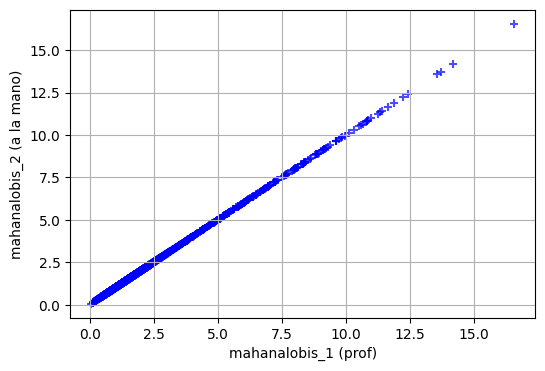

In [12]:
# Comparing results

plt.figure(figsize=(6,4))
plt.scatter(mahanalobis_1(X), mahanalobis_2, color='blue', alpha=0.7, marker='+')
plt.xlabel("mahanalobis_1 (prof)")
plt.ylabel("mahanalobis_2 (a la mano)")
plt.grid(True)
plt.show()

Our 2 solutions return the same result. (good)

The Mahalanobis distance tells how far a transaction is from the statistical center (the mean), taking into account the covariance between variables (scale + correlation) == It adjusts for scaling and correlation between variables.
Without Σ⁻¹, distance would treat variables as if they were independent (which is wrong). == Euclidiant distance

## Anomaly detection


The squared Mahalanobis distance follows a **χ² distribution** with `K` degrees of freedom (number of variables; here, 4).

This allows us to compute a threshold that statistically flags outliers.
For example, the **95th percentile** means we flag only the top 5% most extreme values.
Squared Mahalanobis distances above this threshold are considered anomalies/frauds.


Intuition:
If $D_M^2$ is small → transaction is normal.  
If $D_M^2$ is large → transaction is unusual → possible fraud.


In [13]:
# identiy extreme suspicious transactions (high Mahalanobis distance)

# Degrees of freedom = number of variables
K = X.shape[1]

# Threshold at 95% quantile
alpha = 0.05
threshold = chi2.ppf(1 - alpha, df=K)
print(f"95% Chi-square threshold: {threshold:.2f}")

# Flag anomalies
result=X.copy()
result["mahanalobis_2"] = mahanalobis_2
result["mahanalobis_2_squared"] = mahalanobis_2_squared
result["is_fraud"] = mahalanobis_2_squared > threshold

# How many anomalies
print(f"Total anomalies detected: {result['is_fraud'].sum()}")
print(f"Percentage of transactions flagged as anomalies: {result['is_fraud'].sum()/len(result)*100:.2f}%")
print(result.head())


95% Chi-square threshold: 9.49
Total anomalies detected: 494
Percentage of transactions flagged as anomalies: 4.94%
   IP_Reputation_Score  Transaction_vs_Avg  Log_Amount  Log_Items  \
0            84.242491          -64.575520    3.232908   3.511498   
1            89.950839          108.109227    2.477164   2.643092   
2            69.661417         -130.487596    4.390156   4.403226   
3            73.230538          -14.848716    3.674951   3.781202   
4            61.392552          207.687191    2.683943   2.789412   

   mahanalobis_2  mahanalobis_2_squared  is_fraud  
0       0.772006               0.595993     False  
1       1.213570               1.472752     False  
2       1.814902               3.293869     False  
3       1.042554               1.086919     False  
4       2.032571               4.131344     False  


In [14]:
# Convert True/False to 1/0
my_predictions = result['is_fraud'].astype(int)

# Export as CSV without header or index
df_to_submit = pd.DataFrame(my_predictions)
df_to_submit.to_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW1/predictions.csv', header=False, index=False)


## Visualization

with ai- generated code

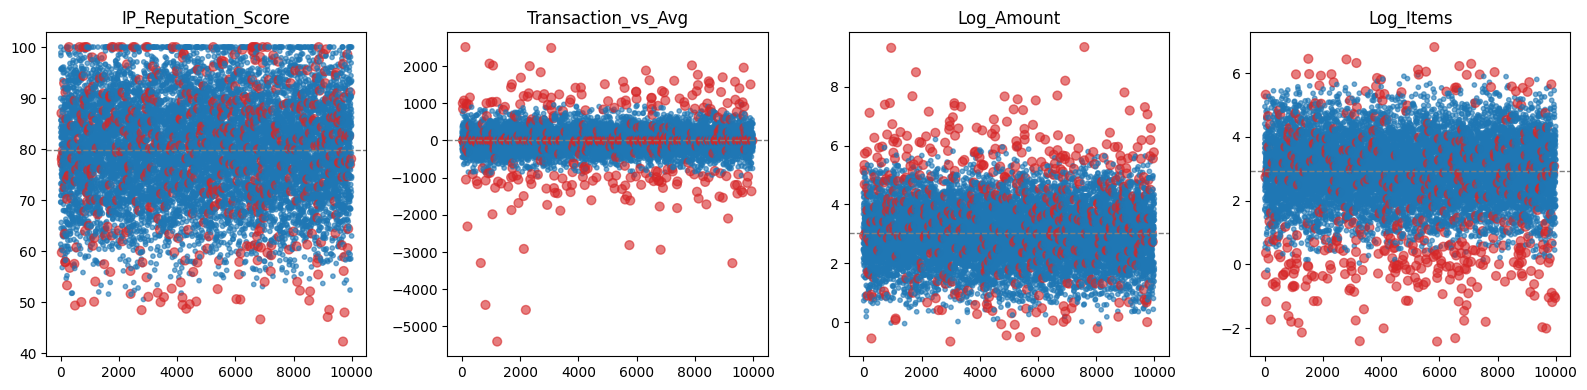

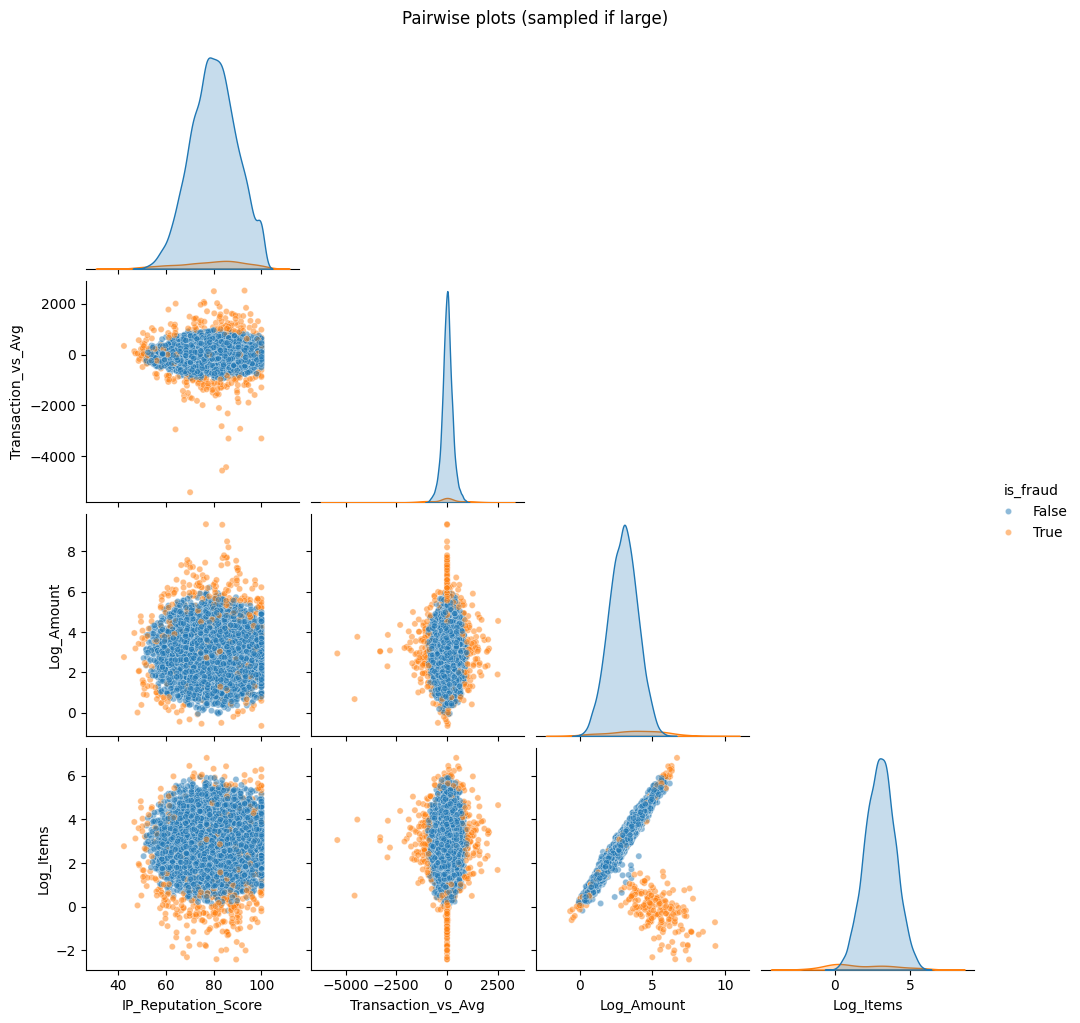

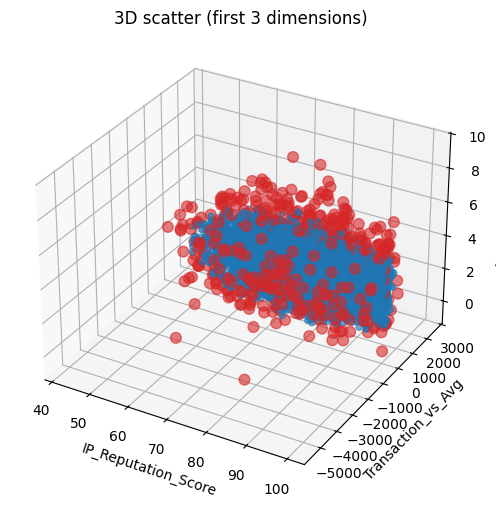

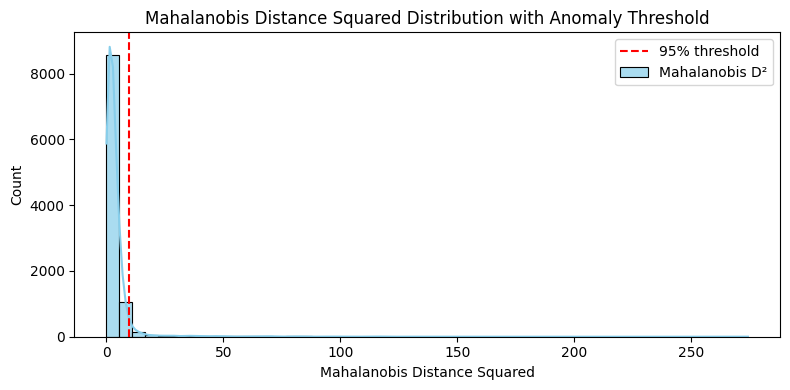

In [15]:

# Visualize detected outliers (per-dimension + 3D + PCA 2D)
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# ensure result contains distances and flag
data_vis = result.copy()

# 1) Per-dimension scatter with anomalies highlighted
fig, axes = plt.subplots(1, len(X.columns), figsize=(4*len(X.columns), 4))
for i, col in enumerate(X.columns):
    ax = axes[i] if len(X.columns) > 1 else axes
    colors = data_vis['is_fraud'].map({False: 'C0', True: 'C3'})
    sizes = data_vis['is_fraud'].map({False: 10, True: 40})
    ax.scatter(range(len(data_vis)), data_vis[col], c=colors, s=sizes, alpha=0.6)
    ax.set_title(col)
    ax.axhline(data_vis[col].mean(), color='gray', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

# 4) Pairplot colored by anomaly flag (useful for 2D pairwise visualization)
# (may be slow for large n; limit sample if needed)
sample = data_vis #if len(data_vis) <= 2000 else data_vis.sample(2000, random_state=0)
sns.pairplot(sample[X.columns.tolist() + ['is_fraud']], hue='is_fraud', corner=True, plot_kws={'alpha':0.5, 's':20})
plt.suptitle('Pairwise plots (sampled if large)', y=1.02)
plt.show()

# 5) 3D scatter using first three columns
if len(X.columns) >= 3:
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data_vis.iloc[:,0], data_vis.iloc[:,1], data_vis.iloc[:,2],
               c=data_vis['is_fraud'].map({False:'C0', True:'C3'}),
               s=data_vis['is_fraud'].map({False:20, True:60}), alpha=0.6)
    ax.set_xlabel(X.columns[0])
    ax.set_ylabel(X.columns[1])
    ax.set_zlabel(X.columns[2])
    plt.title('3D scatter (first 3 dimensions)')
    plt.show()

# 7) Mahalanobis-squared distribution with threshold line
plt.figure(figsize=(8,4))
sns.histplot(data_vis['mahanalobis_2_squared'], bins=50, kde=True, color='skyblue', label='Mahalanobis D²',alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Mahalanobis Distance Squared")
plt.ylabel("Count")
plt.title("Mahalanobis Distance Squared Distribution with Anomaly Threshold")
plt.legend()
plt.tight_layout()
plt.show()


# MCC using the correction

In [16]:
from sklearn.metrics import matthews_corrcoef

df_solution = pd.read_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW1/fraud_homework_solution.csv')
out_true = df_solution.to_numpy().flatten()

mcc = matthews_corrcoef(out_true, my_predictions)
print('MCC using the Mahanalobis with log transformation only: ' + str(round(mcc,3)))


MCC using the Mahanalobis with log transformation only: 0.571
